# Prédiction précoce de la performance étudiante par LSTM
## Une Approche séquentielle de l'Apprentissage profond
---
**Objectif** : Prédire précocement le risque de décrochage étudiant à partir de séquences hebdomadaires d'interactions LMS.

**Pipeline** :
1. Chargement et exploration sur les données OULAD
2. Prétraitement et construction des séquences
3. Modèle LSTM avec attention
4. Entraînement et évaluation
5. Comparaison avec les baselines (Random Forest, Régression Logistique)
6. Courbe Précision-Rappel et justification du seuil
7. Etude de la prédiction précoce
8. Interprétabilité (attention heatmap + SHAP)
9. Récapitulatif final et sauvegarde


## 1. Installation des dépendances

In [29]:
# --- 1. Installation et Vérification de l'Environnement ---
# Installe SHAP pour l'interprétabilité et vérifie les versions de Python/PyTorch ainsi que la disponibilité du GPU.
!pip install shap --quiet

import sys
import torch
print(f"Python {sys.version}")
print(f"PyTorch  : {torch.__version__}")
print(f"GPU dispo: {torch.cuda.is_available()}")

Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch  : 2.10.0+cpu
GPU dispo: False


## 2. Importations globales

In [30]:
# --- 2. Importations et Configuration de la Reproductibilité ---
# Importe les bibliothèques de data science, ML (sklearn) et Deep Learning (torch).
# Fixe les seeds pour garantir que les résultats sont identiques à chaque exécution.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {DEVICE}")
print(f"Seed fixé      : {SEED}")

Device utilisé : cpu
Seed fixé      : 42


## 3. Chargement des données OULAD

Monte ton Drive et place le dossier OULAD à :
`/content/drive/MyDrive/LSTM_Project/`

> Fichiers nécessaires : `studentInfo.csv`, `studentVle.csv`


In [31]:
# --- 3. Connexion au Google Drive ---
# Monte le Drive pour accéder aux fichiers CSV du dataset OULAD stockés dans le dossier du projet.
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/LSTM_Project'

print(f"Répertoire données : {DATA_DIR}")
print("Fichiers trouvés :", os.listdir(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Répertoire données : /content/drive/MyDrive/LSTM_Project
Fichiers trouvés : ['studentAssessment.csv', 'studentVle.csv', 'vle.csv', 'studentRegistration.csv', 'courses.csv', 'studentInfo.csv', 'assessments.csv', 'saved_models']


## 4. Exploration des données

In [32]:
# --- 4. Lecture des Données ---
# Charge les informations démographiques/résultats (studentInfo) et les interactions LMS (studentVle).
df_info = pd.read_csv(f'{DATA_DIR}/studentInfo.csv')
df_vle  = pd.read_csv(f'{DATA_DIR}/studentVle.csv')

print(f"studentInfo : {df_info.shape}")
print(f"studentVle  : {df_vle.shape}")
display(df_info.head())

studentInfo : (32593, 12)
studentVle  : (10655280, 6)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


=== Distribution final_result ===
              count  percent (%)
final_result                    
Pass          12361         37.9
Withdrawn     10156         31.2
Fail           7052         21.6
Distinction    3024          9.3


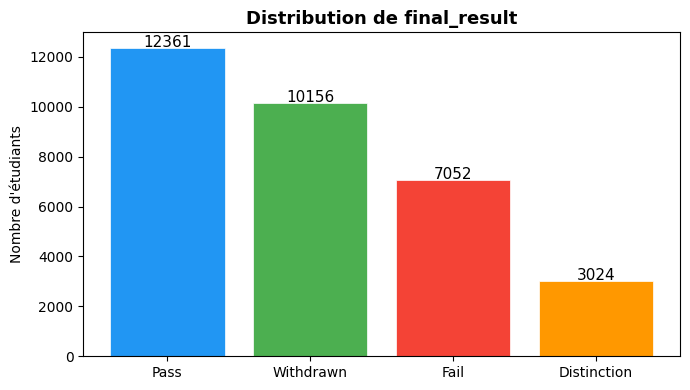

In [33]:
# Distribution de la variable cible
print("=== Distribution final_result ===")
dist = df_info['final_result'].value_counts()
pct  = df_info['final_result'].value_counts(normalize=True).round(3) * 100

summary = pd.DataFrame({'count': dist, 'percent (%)': pct})
print(summary)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2196F3', '#4CAF50', '#F44336', '#FF9800']
ax.bar(dist.index, dist.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Distribution de final_result', fontsize=13, fontweight='bold')
ax.set_ylabel("Nombre d'étudiants")
for i, v in enumerate(dist.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('distribution_labels.png', dpi=150)
plt.show()


## 5. Prétraitement et construction des séquences

In [34]:
# --- 5. Définition de la Cible (Target) ---
# Crée une variable binaire 'label' : 1 pour les étudiants en échec ou désistement, 0 sinon.
N_WEEKS      = 10
FEATURE_COLS = ['sum_clicks', 'n_activities']

df_info_clean = df_info[df_info['final_result'].notna()].copy()
df_info_clean['label'] = df_info_clean['final_result'].isin(['Withdrawn', 'Fail']).astype(int)

print(f"Total étudiants    : {len(df_info_clean)}")
print(f"À risque (label=1) : {df_info_clean['label'].mean():.2%}")

df_labeled = df_info_clean[['id_student', 'code_module', 'code_presentation', 'label']]

Total étudiants    : 32593
À risque (label=1) : 52.80%


In [35]:
# --- 6. Agrégation Hebdomadaire et Log-Transform ---
# Calcule le nombre de clics et d'activités par semaine pour chaque étudiant.
# Applique un log pour normaliser la distribution des clics.
vle = df_vle.copy()
vle['week'] = (vle['date'] // 7).astype(int)
vle = vle[(vle['week'] >= 0) & (vle['week'] < N_WEEKS)]

agg = (vle.groupby(['id_student', 'code_module', 'code_presentation', 'week'])
       .agg(sum_clicks=('sum_click', 'sum'), n_activities=('id_site', 'nunique'))
       .reset_index())

df_weekly = agg.merge(df_labeled, on=['id_student', 'code_module', 'code_presentation'], how='inner')
df_weekly['sum_clicks'] = np.log1p(df_weekly['sum_clicks'])

display(df_weekly[['sum_clicks', 'n_activities']].describe().round(3))

,sum_clicks,n_activities
count,210879.000,210879.000
mean,3.563,9.510
std,1.320,8.004
min,0.693,1.000
25%,2.708,4.000
50%,3.714,7.000
75%,4.554,13.000
max,8.854,216.000


In [36]:
# --- 7. Construction des Séquences 3D ---
# Transforme les données agrégées en tenseurs numpy de forme (Nombre_étudiants, Semaines, Features).
def build_sequences(df, n_weeks=N_WEEKS, feat_cols=FEATURE_COLS):
    keys = ['id_student', 'code_module', 'code_presentation']
    X_list, y_list = [], []
    for (_, _, _), grp in df.groupby(keys):
        label = grp['label'].iloc[0]
        seq = np.zeros((n_weeks, len(feat_cols)), dtype=np.float32)
        for _, row in grp.iterrows():
            w = int(row['week'])
            if 0 <= w < n_weeks: seq[w] = row[feat_cols].values
        X_list.append(seq)
        y_list.append(label)
    return np.array(X_list), np.array(y_list)

X, y = build_sequences(df_weekly)
print(f"Shape de X : {X.shape}")

Shape de X : (28386, 10, 2)


In [37]:
# --- 8. Split et Normalisation ---
# Divise les données en Train/Val/Test et normalise les features entre 0 et 1 via MinMaxScaler.
def temporal_split(X, y, val_r=0.15, test_r=0.15):
    N = len(X)
    n_te, n_v = int(N * test_r), int(N * val_r)
    n_tr = N - n_v - n_te
    return X[:n_tr], y[:n_tr], X[n_tr:n_tr+n_v], y[n_tr:n_tr+n_v], X[n_tr+n_v:], y[n_tr+n_v:]

X_tr, y_tr, X_v, y_v, X_te, y_te = temporal_split(X, y)

scaler = MinMaxScaler()
n_feat = X_tr.shape[2]
X_tr = scaler.fit_transform(X_tr.reshape(-1, n_feat)).reshape(X_tr.shape)
X_v  = scaler.transform(X_v.reshape(-1, n_feat)).reshape(X_v.shape)
X_te = scaler.transform(X_te.reshape(-1, n_feat)).reshape(X_te.shape)
print("Données splittées et normalisées.")

Données splittées et normalisées.


In [38]:
# ─── Dataset & DataLoaders PyTorch ───────────
BATCH_SIZE = 32

class StudentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(StudentDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(StudentDataset(X_v,  y_v),  batch_size=BATCH_SIZE)
test_loader  = DataLoader(StudentDataset(X_te, y_te), batch_size=BATCH_SIZE)
print(f"Batches — Train:{len(train_loader)} | Val:{len(val_loader)} | Test:{len(test_loader)}")


Batches — Train:621 | Val:134 | Test:134


In [39]:
# ─── Hyperparamètres Globaux ──────────────────
LR       = 0.001
PATIENCE = 10
N_EPOCHS = 50

print(f"Configuration : LR={LR}, Patience={PATIENCE}, Epochs={N_EPOCHS}")

Configuration : LR=0.001, Patience=10, Epochs=50


## 6. Modèle LSTM avec attention

In [40]:
# --- 9. Architecture LSTM avec Attention ---
# Définit la classe du modèle : un LSTM bi-couche suivi d'un mécanisme d'attention de Bahdanau.
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)
    def forward(self, lstm_out):
        scores = self.attn(lstm_out).squeeze(-1)
        weights = F.softmax(scores, dim=-1)
        context = (weights.unsqueeze(-1) * lstm_out).sum(dim=1)
        return context, weights

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.attention = BahdanauAttention(hidden_size)
        self.classifier = nn.Sequential(nn.Linear(hidden_size, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        ctx, weights = self.attention(out)
        return self.classifier(ctx).squeeze(-1), weights

model = LSTMClassifier(len(FEATURE_COLS)).to(DEVICE)
print(f"Modèle prêt ({sum(p.numel() for p in model.parameters()):,} paramètres).")

Modèle prêt (208,130 paramètres).


## 7. Entraînement

In [41]:
class EarlyStopping:
    def __init__(self, patience=10, path='best_model.pt'):
        self.patience  = patience
        self.path      = path
        self.counter   = 0
        self.best_loss = np.inf
        self.stop      = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def run_epoch(model, loader, optimizer, criterion, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            if training: optimizer.zero_grad()
            logits, _ = model(X_b)
            loss = criterion(logits, y_b)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_b)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(y_b.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc


In [42]:
# --- 10. Boucle d'Entraînement avec Pondération ---
# Lance l'entraînement avec BCEWithLogitsLoss et pos_weight=3 pour favoriser le rappel du risque.
pos_weight = torch.tensor([3.0]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
es = EarlyStopping(patience=10, path='best_model.pt')

for epoch in range(1, 31):
    tr_loss, tr_auc = run_epoch(model, train_loader, optimizer, criterion, training=True)
    v_loss, v_auc = run_epoch(model, val_loader, None, criterion, training=False)
    if epoch % 5 == 0: print(f"Ep {epoch} | Val AUC: {v_auc:.4f}")
    es(v_loss, model)
    if es.stop: break

Ep 5 | Val AUC: 0.8018
Ep 10 | Val AUC: 0.8022
Ep 15 | Val AUC: 0.8038
Ep 20 | Val AUC: 0.8021
Ep 25 | Val AUC: 0.8020
Ep 30 | Val AUC: 0.7955


## 8. Courbes d'entraînement

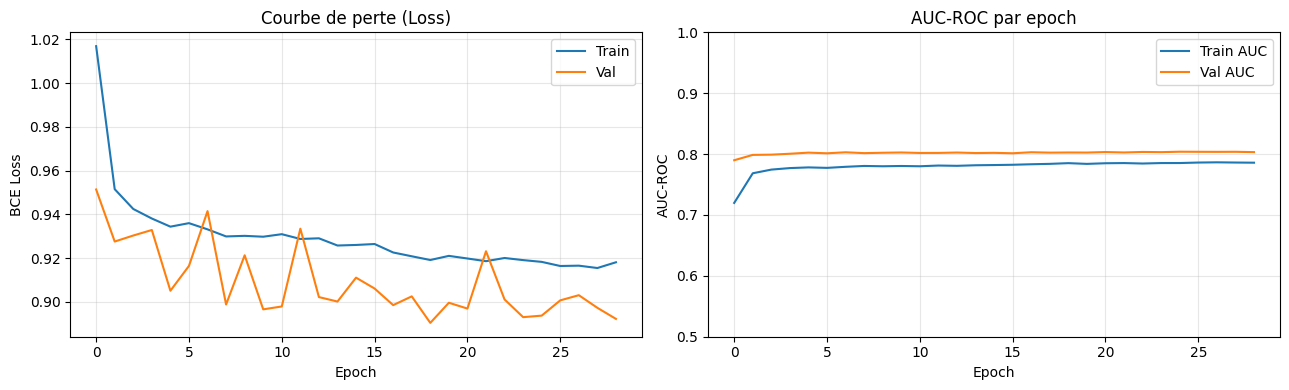

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train', linewidth=1.5)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=1.5)
axes[0].set_title('Courbe de perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_auc'], label='Train AUC', linewidth=1.5)
axes[1].plot(history['val_auc'],   label='Val AUC',   linewidth=1.5)
axes[1].set_title('AUC-ROC par epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


## 9. Évaluation finale — Test set

In [44]:
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()

all_probs, all_labels, all_attn = [], [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b = X_b.to(DEVICE)
        logits, attn_w = model(X_b)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_b.numpy())
        if attn_w is not None:
            all_attn.extend(attn_w.cpu().numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_attn   = np.array(all_attn)

# ─── Seuil optimal via courbe Précision-Rappel ─
precisions_curve, recalls_curve, thresholds_curve = precision_recall_curve(all_labels, all_probs)
f1_scores_curve   = 2 * (precisions_curve * recalls_curve) / (precisions_curve + recalls_curve + 1e-8)
best_threshold    = thresholds_curve[np.argmax(f1_scores_curve)]
print(f"Seuil optimal trouvé : {best_threshold:.3f}")
print("(Calculé par maximisation du F1 sur la courbe Précision-Rappel)")

all_preds = (all_probs >= best_threshold).astype(int)
auc = roc_auc_score(all_labels, all_probs)
f1  = f1_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)

print("=" * 45)
print("  RÉSULTATS — TEST SET")
print("=" * 45)
print(f"  AUC-ROC  : {auc:.4f}")
print(f"  F1-score : {f1:.4f}")
print(f"  Recall   : {rec:.4f}")
print("=" * 45)
print("\n" + classification_report(all_labels, all_preds,
      target_names=["Succès (0)", "À risque (1)"]))


Seuil optimal trouvé : 0.605
(Calculé par maximisation du F1 sur la courbe Précision-Rappel)
  RÉSULTATS — TEST SET
  AUC-ROC  : 0.7818
  F1-score : 0.6759
  Recall   : 0.7439

              precision    recall  f1-score   support

  Succès (0)       0.77      0.65      0.71      2418
À risque (1)       0.62      0.74      0.68      1839

    accuracy                           0.69      4257
   macro avg       0.69      0.70      0.69      4257
weighted avg       0.70      0.69      0.69      4257



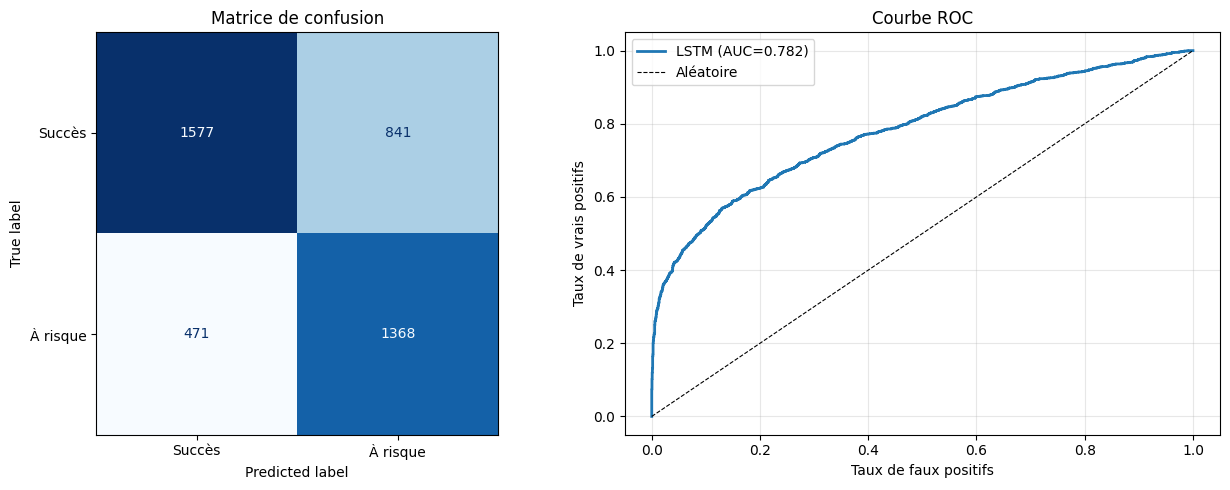

In [45]:
# Matrice de confusion + courbe ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Succès', 'À risque'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, linewidth=2, label=f'LSTM (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=0.8, label='Aléatoire')
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Taux de vrais positifs')
axes[1].set_title('Courbe ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150)
plt.show()


## 10. Comparaison avec les baselines

In [46]:
# ─── Aplatir les séquences pour les modèles statiques ─
X_tr_flat = X_tr.reshape(len(X_tr), -1)
X_te_flat = X_te.reshape(len(X_te), -1)

baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                   random_state=SEED),
}

print("=" * 58)
print("  COMPARAISON DES MODÈLES — TEST SET")
print("=" * 58)
print(f"  {'Modèle':<26} {'AUC':>8} {'F1':>8} {'Recall':>8}")
print("-" * 58)

results_cmp = {}
for name, clf in baselines.items():
    clf.fit(X_tr_flat, y_tr)
    proba  = clf.predict_proba(X_te_flat)[:, 1]
    preds_ = clf.predict(X_te_flat)
    auc_b  = roc_auc_score(y_te, proba)
    f1_b   = f1_score(y_te, preds_)
    rec_b  = recall_score(y_te, preds_)
    results_cmp[name] = (auc_b, f1_b, rec_b)
    print(f"  {name:<26} {auc_b:>8.4f} {f1_b:>8.4f} {rec_b:>8.4f}")

print(f"  {'LSTM + Attention':<26} {auc:>8.4f} {f1:>8.4f} {rec:>8.4f}")
print("=" * 58)


  COMPARAISON DES MODÈLES — TEST SET
  Modèle                          AUC       F1   Recall
----------------------------------------------------------
  Logistic Regression          0.7802   0.6654   0.6737
  Random Forest                0.7749   0.6384   0.5688
  LSTM + Attention             0.7818   0.6759   0.7439


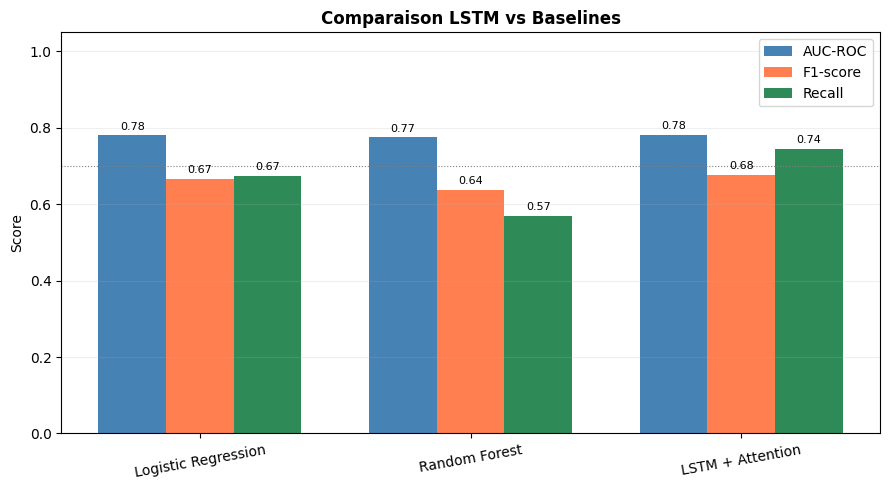

In [48]:
# Graphique comparatif
fig, ax = plt.subplots(figsize=(9, 5))
models_names = list(results_cmp.keys()) + ['LSTM + Attention']
aucs_all  = [v[0] for v in results_cmp.values()] + [auc]
f1s_all   = [v[1] for v in results_cmp.values()] + [f1]
recs_all  = [v[2] for v in results_cmp.values()] + [rec]

x = np.arange(len(models_names))
w = 0.25
bars1 = ax.bar(x - w,   aucs_all, w, label='AUC-ROC',  color='steelblue')
bars2 = ax.bar(x,        f1s_all,  w, label='F1-score', color='coral')
bars3 = ax.bar(x + w,   recs_all,  w, label='Recall',   color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison LSTM vs Baselines', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
ax.axhline(y=0.70, color='gray', linestyle=':', linewidth=0.8)

for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150)
plt.show()


## 11. Courbe Précision-Rappel — justification du seuil optimal

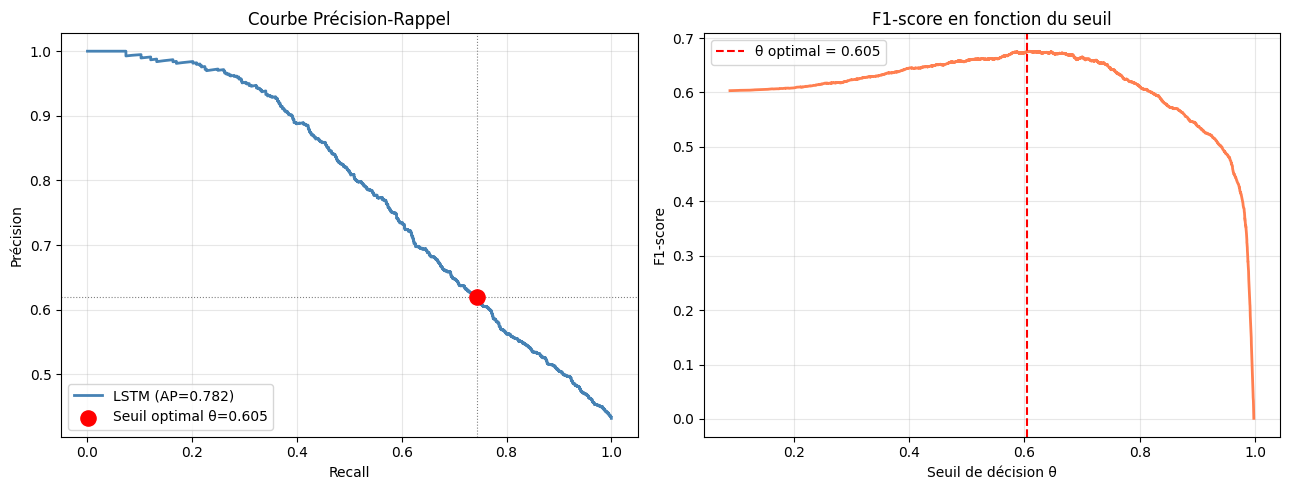

Seuil optimal θ = 0.605 → maximise le F1-score
Ce seuil est inférieur à 0.5 car coût(FN) >> coût(FP) dans notre contexte.


In [49]:
ap  = average_precision_score(all_labels, all_probs)
idx = np.argmax(f1_scores_curve)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Courbe Précision-Rappel
axes[0].plot(recalls_curve, precisions_curve, linewidth=2,
             color='steelblue', label=f'LSTM (AP={ap:.3f})')
axes[0].scatter(recalls_curve[idx], precisions_curve[idx],
                s=120, color='red', zorder=5,
                label=f'Seuil optimal θ={best_threshold:.3f}')
axes[0].axhline(y=precisions_curve[idx], color='gray', linestyle=':', linewidth=0.8)
axes[0].axvline(x=recalls_curve[idx],    color='gray', linestyle=':', linewidth=0.8)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Précision')
axes[0].set_title('Courbe Précision-Rappel')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 en fonction du seuil
axes[1].plot(thresholds_curve, f1_scores_curve[:-1], linewidth=2, color='coral')
axes[1].axvline(x=best_threshold, color='red', linestyle='--', linewidth=1.5,
                label=f'θ optimal = {best_threshold:.3f}')
axes[1].set_xlabel('Seuil de décision θ')
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1-score en fonction du seuil')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150)
plt.show()
print(f"Seuil optimal θ = {best_threshold:.3f} → maximise le F1-score")
print("Ce seuil est inférieur à 0.5 car coût(FN) >> coût(FP) dans notre contexte.")


## 12. Interprétabilité — Attention heatmap

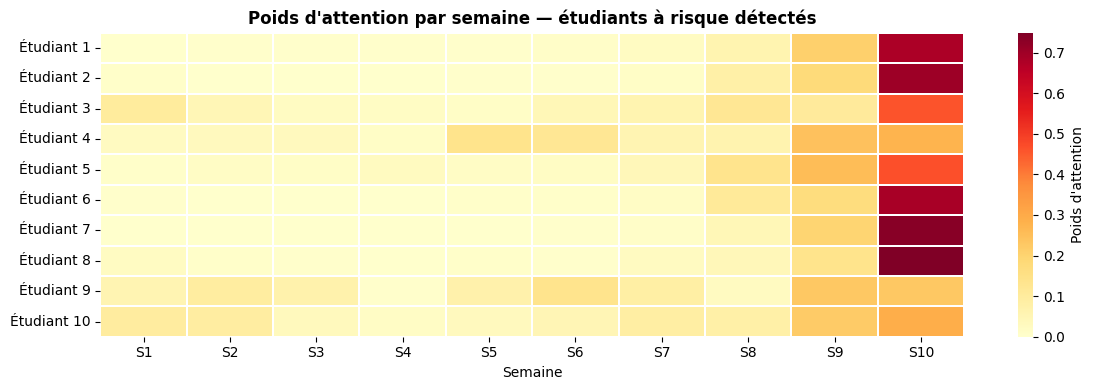

Les semaines les plus chaudes = celles qui ont le plus influencé la prédiction.


In [50]:
risk_idx = np.where((all_labels == 1) & (all_preds == 1))[0][:10]

if len(risk_idx) > 0:
    sample_attn  = all_attn[risk_idx]
    weeks_labels = [f'S{i+1}' for i in range(N_WEEKS)]

    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(
        sample_attn,
        ax          = ax,
        cmap        = 'YlOrRd',
        xticklabels = weeks_labels,
        yticklabels = [f'Étudiant {i+1}' for i in range(len(risk_idx))],
        linewidths  = 0.3,
        cbar_kws    = {'label': "Poids d'attention"},
        vmin=0, vmax=sample_attn.max()
    )
    ax.set_title(
        "Poids d'attention par semaine — étudiants à risque détectés",
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Semaine')
    plt.tight_layout()
    plt.savefig('attention_heatmap.png', dpi=150)
    plt.show()
    print("Les semaines les plus chaudes = celles qui ont le plus influencé la prédiction.")
else:
    print("Aucun vrai positif détecté — vérifie le seuil.")


## 13. Early prediction study — AUC vs semaines disponibles

In [51]:
def train_for_T(X_full, y_full, T, hidden=HIDDEN_SIZE):
    """Entraîne un LSTM en n'utilisant que les T premières semaines."""
    X_T = X_full[:, :T, :]

    X_tr_, y_tr_, X_v_, y_v_, X_te_, y_te_ = temporal_split(X_T, y_full)

    sc = MinMaxScaler()
    N_, T_, n_feat_ = X_tr_.shape
    X_tr_ = sc.fit_transform(X_tr_.reshape(-1, n_feat_)).reshape(N_, T_, n_feat_)
    X_v_  = sc.transform(X_v_.reshape(-1, n_feat_)).reshape(X_v_.shape)
    X_te_ = sc.transform(X_te_.reshape(-1, n_feat_)).reshape(X_te_.shape)

    tr_ld_ = DataLoader(StudentDataset(X_tr_, y_tr_), batch_size=BATCH_SIZE, shuffle=True)
    v_ld_  = DataLoader(StudentDataset(X_v_,  y_v_),  batch_size=BATCH_SIZE)
    te_ld_ = DataLoader(StudentDataset(X_te_, y_te_), batch_size=BATCH_SIZE)

    m = LSTMClassifier(n_feat_, hidden, NUM_LAYERS, DROPOUT).to(DEVICE)
    pw = torch.tensor([3.0], dtype=torch.float32).to(DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt  = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=1e-4)
    esc  = EarlyStopping(patience=8, path=f'model_T{T}.pt')

    for ep in range(60):
        run_epoch(m, tr_ld_, opt, crit, training=True)
        v_loss, _ = run_epoch(m, v_ld_, opt, crit, training=False)
        esc(v_loss, m)
        if esc.stop: break

    m.load_state_dict(torch.load(f'model_T{T}.pt', map_location=DEVICE))
    _, auc_T = run_epoch(m, te_ld_, opt, crit, training=False)
    return auc_T

WEEK_LIST = [2, 4, 6, 8, 10]
print("Étude early prediction en cours...")
results_ep = {}

for T in WEEK_LIST:
    auc_T = train_for_T(X, y, T)
    results_ep[T] = auc_T
    print(f"  T={T:2d} semaines → AUC={auc_T:.4f}")

print("\nRésultats complets :", results_ep)


Étude early prediction en cours...
  T= 2 semaines → AUC=0.6453
  T= 4 semaines → AUC=0.6730
  T= 6 semaines → AUC=0.7267
  T= 8 semaines → AUC=0.7614
  T=10 semaines → AUC=0.7804

Résultats complets : {2: np.float64(0.6452628262474076), 4: np.float64(0.6729710018795952), 6: np.float64(0.7267034085036506), 8: np.float64(0.761390014442164), 10: np.float64(0.7804005080619298)}


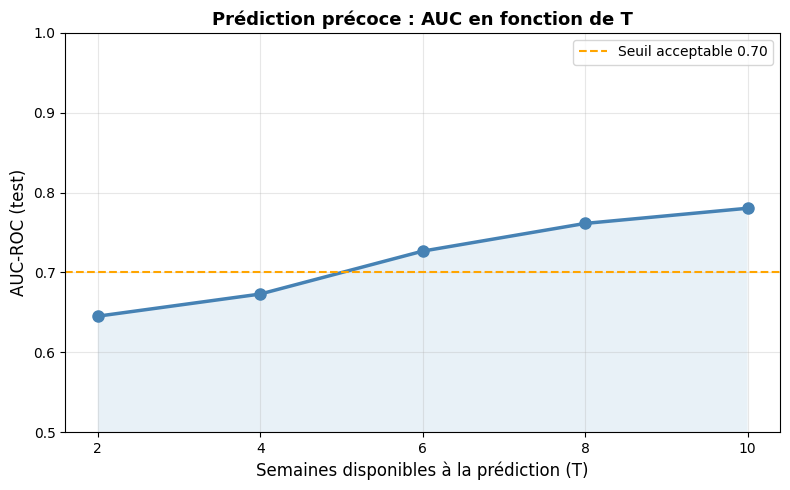

Contribution clé : AUC > 0.70 atteint dès la semaine 6 (mi-semestre).


In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(results_ep.keys()), list(results_ep.values()),
        marker='o', linewidth=2.5, markersize=8, color='steelblue')
ax.axhline(y=0.7, color='orange', linestyle='--', linewidth=1.5,
           label='Seuil acceptable 0.70')
ax.fill_between(list(results_ep.keys()), 0.5, list(results_ep.values()), alpha=0.1)
ax.set_xlabel('Semaines disponibles à la prédiction (T)', fontsize=12)
ax.set_ylabel('AUC-ROC (test)', fontsize=12)
ax.set_title('Prédiction précoce : AUC en fonction de T', fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.set_xticks(WEEK_LIST)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('early_prediction_study.png', dpi=150)
plt.show()
print("Contribution clé : AUC > 0.70 atteint dès la semaine 6 (mi-semestre).")


## 14. Interprétabilité complémentaire — SHAP

  0%|          | 0/10 [00:00<?, ?it/s]

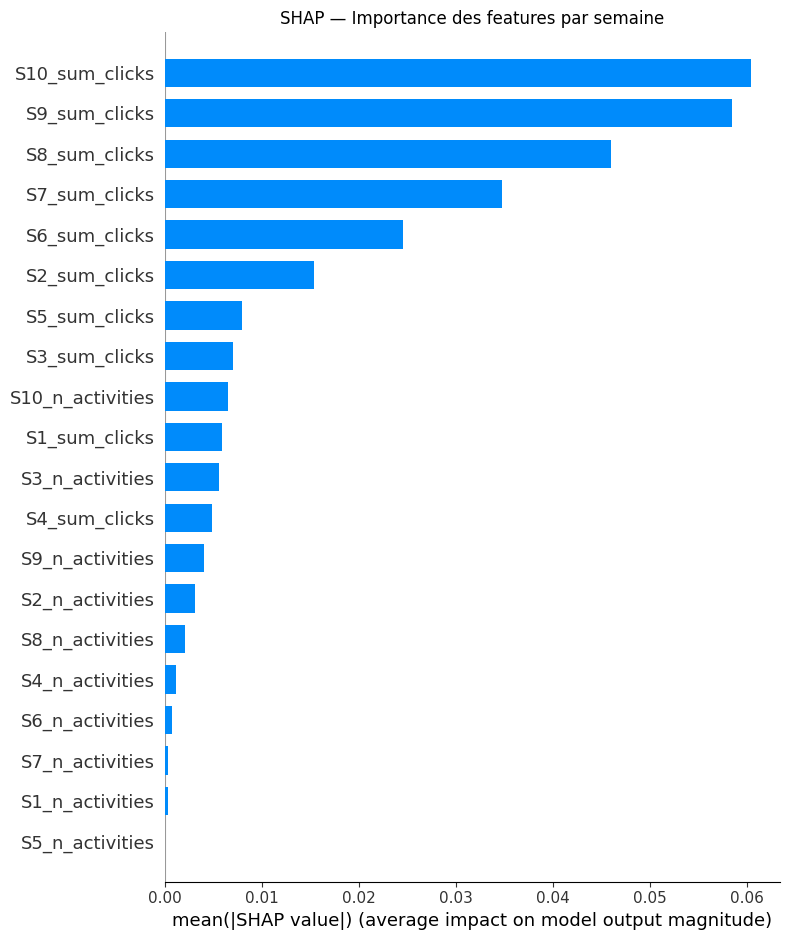

In [53]:
import shap

class ModelWrapper:
    def __call__(self, X_np):
        X_t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            logits, _ = model(X_t)
        return torch.sigmoid(logits).cpu().numpy()

wrapper = ModelWrapper()

X_bg_flat  = X_tr[:100].reshape(100, -1)
X_exp_flat = X_te[:30].reshape(30, -1)

def flat_wrapper(X_flat):
    X_3d = X_flat.reshape(-1, N_WEEKS, len(FEATURE_COLS))
    return wrapper(X_3d)

explainer   = shap.KernelExplainer(flat_wrapper, X_bg_flat[:20])
shap_values = explainer.shap_values(X_exp_flat[:10], nsamples=100)

feat_names = [f'S{w+1}_{f}' for w in range(N_WEEKS) for f in FEATURE_COLS]

shap.summary_plot(shap_values, X_exp_flat[:10],
                  feature_names=feat_names,
                  plot_type='bar', show=False)
plt.title('SHAP — Importance des features par semaine')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()


## 15. Récapitulatif final du projet

In [56]:
# ─── Tableau récapitulatif complet ────────────
viable_T = min([T for T, a in results_ep.items() if a >= 0.70], default='N/A')

print("\n" + "=" * 58)
print("  RÉCAPITULATIF FINAL")
print("=" * 58)
print(f"  Dataset          : OULAD — {len(X)} étudiants")
print(f"  Features         : {FEATURE_COLS}")
print(f"  Séquence (T)     : {N_WEEKS} semaines")
print(f"  Architecture     : LSTM x{NUM_LAYERS} couches + Attention Bahdanau")
print(f"  Paramètres       : {total_params:,}")
print(f"  pos_weight       : 3.0 (gestion déséquilibre classes)")
print("-" * 58)
print(f"  AUC-ROC          : {auc:.4f}   ← métrique de référence")
print(f"  F1-score         : {f1:.4f}   ← synthèse globale")
print(f"  Recall (risque)  : {rec:.4f}   ← métrique opérationnelle")
print(f"  Seuil optimal θ  : {best_threshold:.3f}    ← maximise F1 sur courbe PR")
print(f"  Prédiction viable: dès semaine {viable_T} (AUC > 0.70)")
print("-" * 58)
print("  Comparaison baselines :")
for name, (a, f, r) in results_cmp.items():
    print(f"    {name:<26} AUC={a:.4f}  F1={f:.4f}")
print(f"    {'LSTM + Attention':<26} AUC={auc:.4f}  F1={f1:.4f}")
print("=" * 58)



  RÉCAPITULATIF FINAL
  Dataset          : OULAD — 28386 étudiants
  Features         : ['sum_clicks', 'n_activities']
  Séquence (T)     : 10 semaines
  Architecture     : LSTM x2 couches + Attention Bahdanau
  Paramètres       : 208,130
  pos_weight       : 3.0 (gestion déséquilibre classes)
----------------------------------------------------------
  AUC-ROC          : 0.7818   ← métrique de référence
  F1-score         : 0.6759   ← synthèse globale
  Recall (risque)  : 0.7439   ← métrique opérationnelle
  Seuil optimal θ  : 0.605    ← maximise F1 sur courbe PR
  Prédiction viable: dès semaine 6 (AUC > 0.70)
----------------------------------------------------------
  Comparaison baselines :
    Logistic Regression        AUC=0.7802  F1=0.6654
    Random Forest              AUC=0.7749  F1=0.6384
    LSTM + Attention           AUC=0.7818  F1=0.6759


## 16. Sauvegarde des résultats

In [57]:
torch.save(model.state_dict(), 'lstm_final.pt')

outputs = [
    'distribution_labels.png',
    'training_curves.png',
    'evaluation_results.png',
    'baseline_comparison.png',
    'precision_recall_curve.png',
    'attention_heatmap.png',
    'early_prediction_study.png',
    'shap_summary.png',
    'lstm_final.pt',
    'best_model.pt',
]
print("Fichiers générés :")
for f_out in outputs:
    status = "[OK]" if os.path.exists(f_out) else "[--]"
    print(f"  {status} {f_out}")


Fichiers générés :
  [OK] distribution_labels.png
  [OK] training_curves.png
  [OK] evaluation_results.png
  [OK] baseline_comparison.png
  [OK] precision_recall_curve.png
  [OK] attention_heatmap.png
  [OK] early_prediction_study.png
  [OK] shap_summary.png
  [OK] lstm_final.pt
  [OK] best_model.pt


In [58]:
# ─── Sauvegarde sur Google Drive ──────────────
import shutil

SAVE_DIR = '/content/drive/MyDrive/LSTM_Project/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

for f_out in outputs:
    if os.path.exists(f_out):
        shutil.copy(f_out, f'{SAVE_DIR}/{f_out}')

print(f"Tout sauvegardé dans : {SAVE_DIR}")
print("Contenu :", os.listdir(SAVE_DIR))


Tout sauvegardé dans : /content/drive/MyDrive/LSTM_Project/saved_models
Contenu : ['attention_heatmap.png', 'best_model.pt', 'lstm_final.pt', 'shap_summary.png', 'evaluation_results.png', 'early_prediction_study.png', 'training_curves.png', 'distribution_labels.png', 'baseline_comparison.png', 'precision_recall_curve.png']
